In [15]:
from typing import TypedDict, List, Sequence, Annotated
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, BaseMessage, ToolMessage, SystemMessage
from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode
from dotenv import load_dotenv

In [16]:
load_dotenv()

True

In [17]:
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]

In [18]:
@tool
def add(a: int, b: int):
    """这是个加法算数工具"""
    return a + b

In [19]:
tools = [add]

In [20]:
model = ChatOpenAI(model="qwen-plus").bind_tools(tools)

In [31]:
def llm(state: AgentState) -> AgentState:
    system_prompt = SystemMessage(content="你是一个智能助手，可以在适当情况下调用工具")
    response = model.invoke([system_prompt] + state["messages"])
    return {"messages": [response]}

In [32]:
def continue_node(state: AgentState) -> str:
    last_message = state["messages"][-1]
    if not last_message.tool_calls:
        return "end"
    else:
        return "continue"

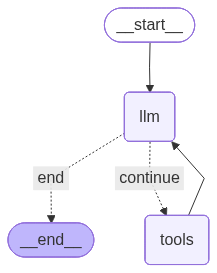

In [33]:
graph = StateGraph(AgentState)
graph.add_node("llm", llm)
tool_node = ToolNode(tools=tools)
graph.add_node("tools", tool_node)
graph.add_edge(START, "llm")
graph.add_edge("tools", "llm")
graph.add_conditional_edges(
    # start node
    "llm",
    continue_node,
    {
        "continue": "tools",
        "end": END
    }
)

graph.compile()

In [36]:
def print_stream(stream):
    for s in stream:
        message = s["messages"][-1]
        if isinstance(message, tuple):
            print(message)
        else:
            message.pretty_print()

In [37]:
app = graph.compile()
print_stream(app.stream({"messages": "帮我计算1+1,然后用结果再加上9算新结果"}, stream_mode="values"))

================================ Human Message =================================

帮我计算1+1,然后用结果再加上9算新结果
================================== Ai Message ==================================
Tool Calls:
  add (call_1105149d4c3b4ff092e295)
 Call ID: call_1105149d4c3b4ff092e295
  Args:
    a: 1
    b: 1
================================= Tool Message =================================
Name: add

2
================================== Ai Message ==================================
Tool Calls:
  add (call_53943081c3274f788b6bd0)
 Call ID: call_53943081c3274f788b6bd0
  Args:
    a: 2
    b: 9
================================= Tool Message =================================
Name: add

11
================================== Ai Message ==================================

计算结果是11。
